AydinDemir.com | created: Mar 06, 2026 | modified: Mar 06, 2026

---

## Process AFAD-TADAS Strong Ground Motion Data

### 1. Read and Plot AFAD Raw Acceleration Record

Duration: 120.0 sec
PGA (E-W): 2.217 g
PGA (N-S): 2.208 g
PGA (U-D): 1.991 g


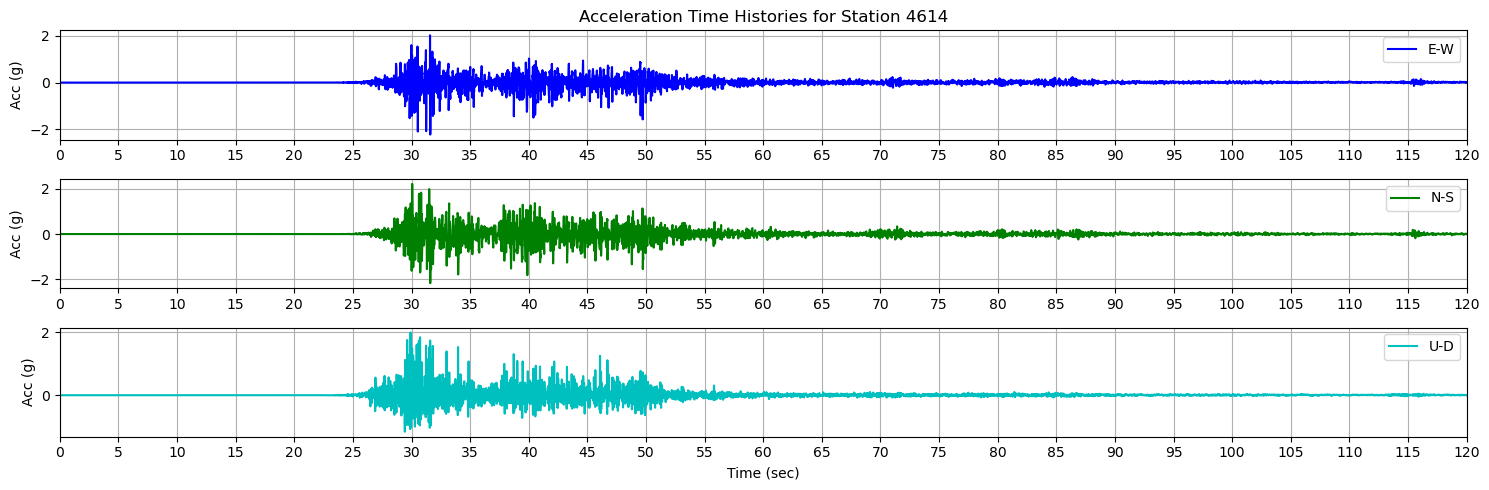

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import os

# Event website
# https://tadas.afad.gov.tr/event-detail/17966

# define record parameters
st_id    = 4614     # Station ID
dt       = 0.01     # [sec], Time interval of the record
HeaderNo = 64       # Number of Header Lines to be skipped from the file
SF       = 1.0/981  # Scale Factor; AFAD acc unit is given in cm/s^2, so it is converted to the unit of g

# define file path
file_path_E = "EQ_Record_Files/20230206011732_4614_unprocessed_RawAcc_E.asc"  # E-W component
file_path_N = "EQ_Record_Files/20230206011732_4614_unprocessed_RawAcc_N.asc"  # N-S component
file_path_U = "EQ_Record_Files/20230206011732_4614_unprocessed_RawAcc_U.asc"  # U-D component

# read the record file
acc_data_E = np.loadtxt(file_path_E, skiprows=HeaderNo, unpack=True)  # E-W component
acc_data_N = np.loadtxt(file_path_N, skiprows=HeaderNo, unpack=True)  # N-S component
acc_data_U = np.loadtxt(file_path_U, skiprows=HeaderNo, unpack=True)  # U-D component

acc_raw_E = acc_data_E*SF  # E-W component
acc_raw_N = acc_data_N*SF  # N-S component
acc_raw_U = acc_data_U*SF  # U-D component

# record properties
dur_raw = len(acc_raw_E)*dt - dt 
print(f"Duration: {dur_raw} sec") # duration of the records
t_raw = np.arange(0, len(acc_raw_E)*dt, dt)  # time axis

# Peak ground accelerations
print(f"PGA (E-W): {np.round(max(abs(acc_raw_E)), 3)} g")  # E-W component
print(f"PGA (N-S): {np.round(max(abs(acc_raw_N)), 3)} g")  # N-S component
print(f"PGA (U-D): {np.round(max(abs(acc_raw_U)), 3)} g")  # U-D component

# Plot Ground Motions
fig, xy = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 5)) # Alt alta çizim
xy[0].plot(t_raw, acc_raw_E, color = 'b', label = 'E-W')
xy[0].set(ylabel = 'Acc (g)', title = f'Acceleration Time Histories for Station {st_id}')
xy[0].set_xlim(0, dur_raw)
xy[0].set_xticks(np.arange(0, dur_raw + 1, 5)) 
xy[0].legend()
xy[0].grid()
xy[1].plot(t_raw, acc_raw_N, color = 'g', label = 'N-S')
xy[1].set(ylabel = 'Acc (g)')
xy[1].set_xlim(0, dur_raw)
xy[1].set_xticks(np.arange(0, dur_raw + 1, 5)) 
xy[1].legend()
xy[1].grid()
xy[2].plot(t_raw, acc_raw_U, color = 'c', label = 'U-D')
xy[2].set(xlabel = 'Time (sec)', ylabel = 'Acc (g)')
xy[2].set_xlim(0, dur_raw) 
xy[2].set_xticks(np.arange(0, dur_raw + 1, 5)) 
xy[2].legend() 
xy[2].grid()
fig.tight_layout()
plt.show()

### 2. Time-windowing
Applying a time window to remove unwanted data at the start and end of the record.

If no time window is applied, enter 0 and the full duration of the original record

Duration: 77.01 sec


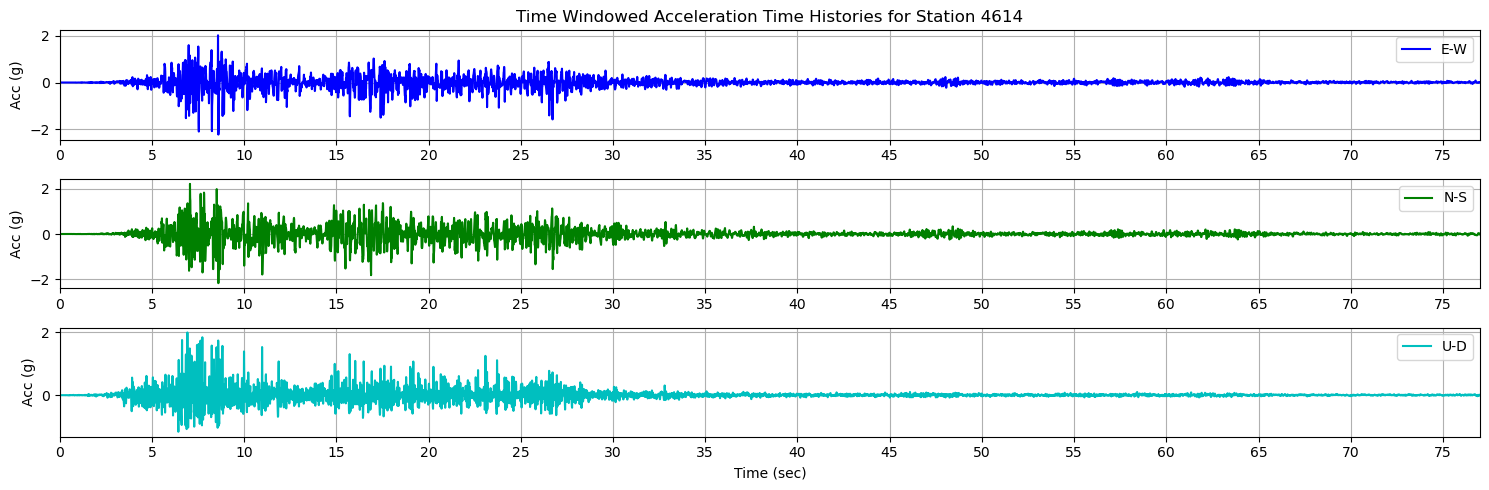

In [2]:
# Define the time range for windowing to trim the start/end of the record
# t1, t2 = 0, dur_raw  # [sec], uncomment for no time window
t1, t2 = 23, 100  # [sec]

acc_raw_E_win = acc_raw_E[int(t1/dt):int(t2/dt) + 1]  # E-W component
acc_raw_N_win = acc_raw_N[int(t1/dt):int(t2/dt) + 1]  # N-S component
acc_raw_U_win = acc_raw_U[int(t1/dt):int(t2/dt) + 1]  # U-D component

t = np.arange(0, len(acc_raw_E_win)*dt, dt) # time interval of the windowed records
dur = len(t)*dt ; print(f"Duration: {dur} sec")

# Plot Ground Motions
fig, xy = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 5))
xy[0].plot(t, acc_raw_E_win, color = 'b', label = 'E-W')
xy[0].set_xlim(0, dur)
xy[0].set_xticks(np.arange(0, dur + 1, 5)) 
xy[0].set(ylabel = 'Acc (g)', title = f'Time Windowed Acceleration Time Histories for Station {st_id}')
xy[0].legend()
xy[0].grid()
xy[1].plot(t, acc_raw_N_win, color = 'g',label = 'N-S')
xy[1].set_xlim(0, dur)
xy[1].set_xticks(np.arange(0, dur + 1, 5)) 
xy[1].set(ylabel = 'Acc (g)')
xy[1].legend()
xy[1].grid()
xy[2].plot(t, acc_raw_U_win, color = 'c', label = 'U-D')
xy[2].set_xlim(0, dur)
xy[2].set_xticks(np.arange(0, dur + 1, 5)) 
xy[2].set(xlabel = 'Time (sec)', ylabel = 'Acc (g)')
xy[2].legend()
xy[2].grid()
fig.tight_layout()
plt.show()

Sampling interval (dt) : 0.01 sec
Sampling frequency (fs): 100.0 Hz
Nyquist frequency (fn) : 50.0 Hz (max resolvable freq.)


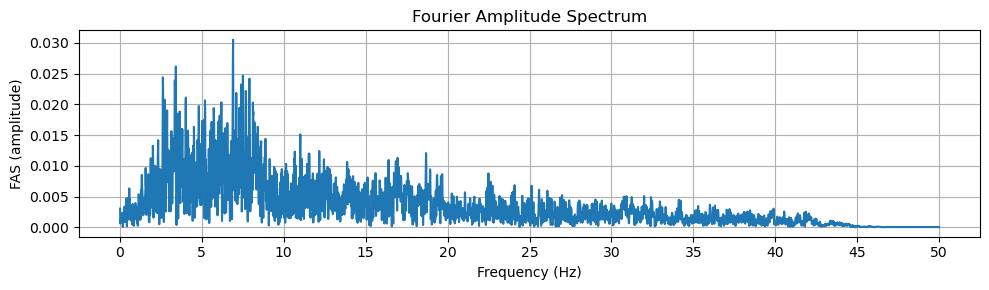

In [3]:
# FFT (FAST FOURIER TRANSFORM)
# Signal properties
fs = 1.0 / dt                   # sampling frequency (Hz)
fn = fs / 2.0                   # Nyquist frequency (Hz) = max resolvable freq.
print(f"Sampling interval (dt) : {dt} sec")
print(f"Sampling frequency (fs): {fs} Hz")
print(f"Nyquist frequency (fn) : {fn} Hz (max resolvable freq.)")

# FFT of corrected acceleration.
# np.fft.fft returns complex numbers (a + i b).
acc = acc_raw_E_win
# acc = acc_raw_N_win
# acc = acc_raw_U_win

acc_fft = np.fft.fft(acc)

n = len(acc)
n_half = n // 2

# Frequency axis (Hz) for the positive frequencies (exclude 0 Hz here)
freq = np.arange(1, n_half + 1) / (n * dt)

# Fourier Amplitude Spectrum (single-sided, scaled)
fas_raw = 2.0 * np.abs(acc_fft[1:n_half + 1]) / n

# Plot: Fourier Amplitude Spectrum (FAS)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(freq, fas_raw)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("FAS (amplitude)")
ax.set_title("Fourier Amplitude Spectrum")
ax.set_xticks(np.arange(0, fn + 5, 5))  # X-axis ticks every 5 Hz
ax.grid(True)
fig.tight_layout()
plt.show()

### 3. Compute Raw and Filtered Velocity and Displacement Time Histories from Acceleration

The records filtered.


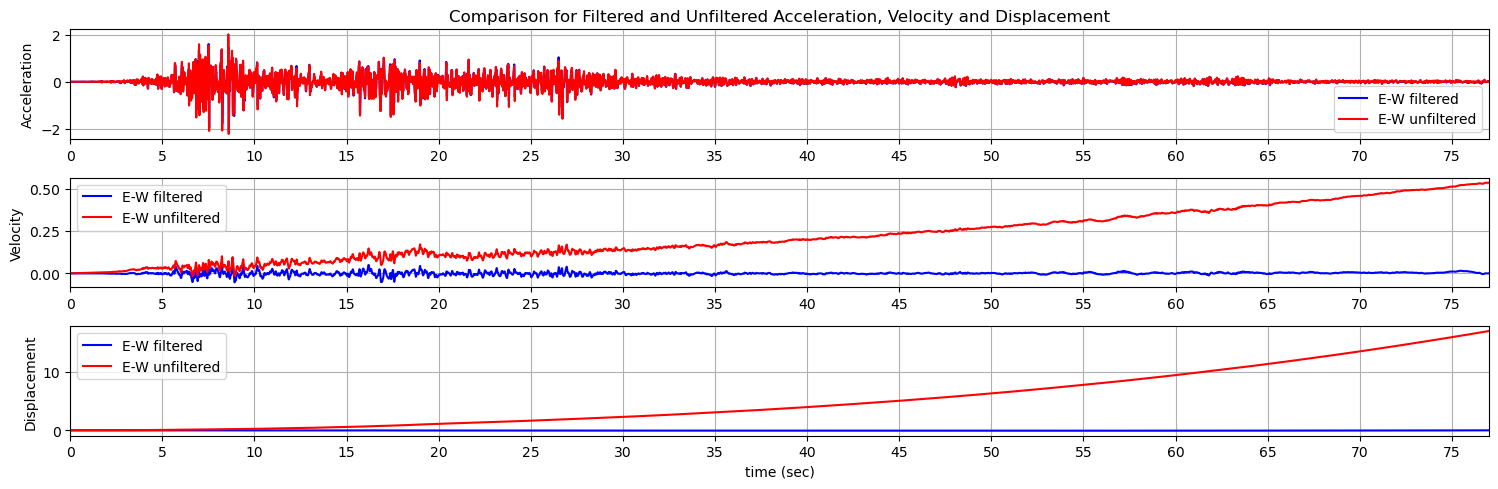

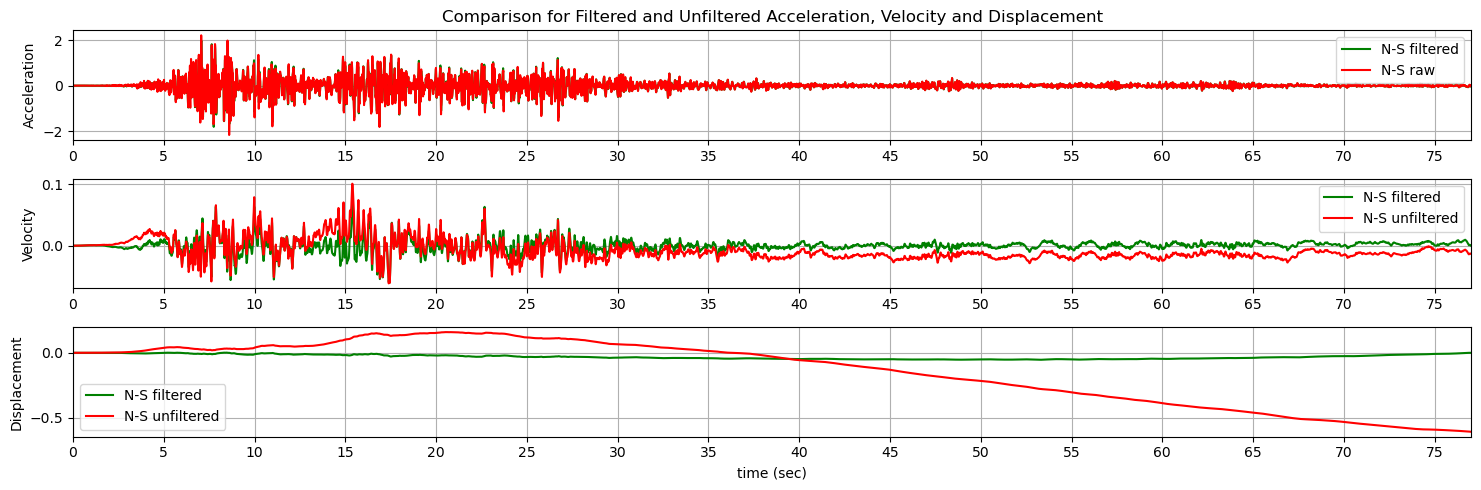

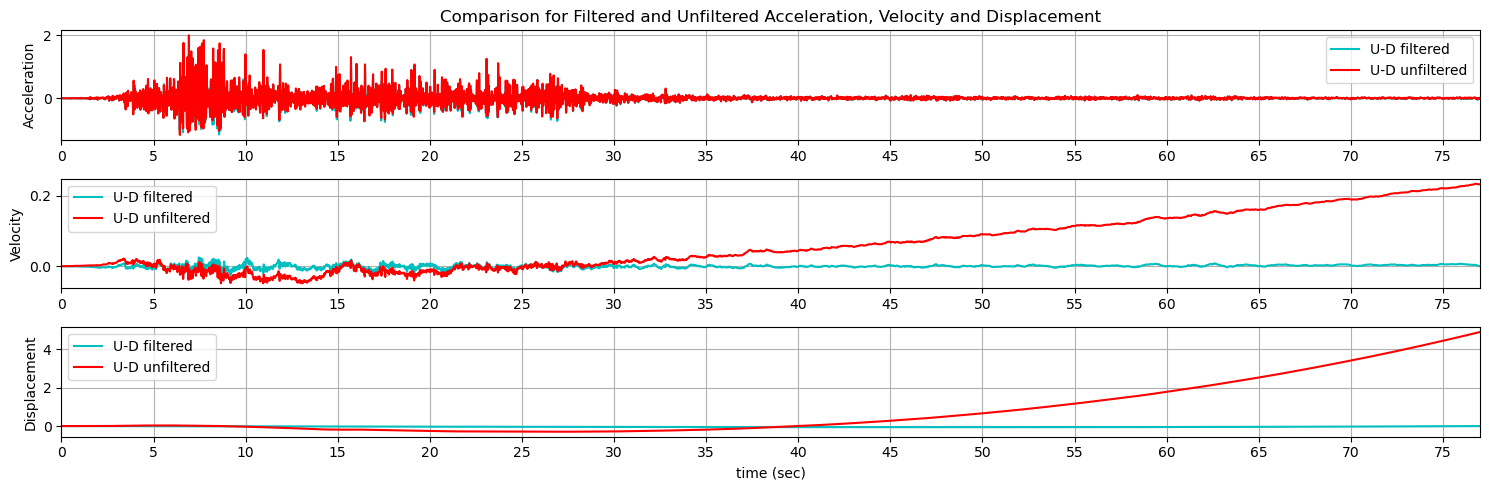

In [4]:
# Raw Record: Compute Velocity time history by Integration of acceleration 
vel_raw_E_win = np.cumsum(acc_raw_E_win)*dt    # E-W component
vel_raw_N_win = np.cumsum(acc_raw_N_win)*dt    # N-S component
vel_raw_U_win = np.cumsum(acc_raw_U_win)*dt    # U-D component

# Raw Record: Compute Displacement time history by Integration of velocity 
dis_raw_E_win = np.cumsum(vel_raw_E_win)*dt    # E-W component
dis_raw_N_win = np.cumsum(vel_raw_N_win)*dt    # N-S component
dis_raw_U_win = np.cumsum(vel_raw_U_win)*dt    # U-D component


# Application of Bandpass Filtering with linear detrend
def filterAFAD(acc, dt, fclow, fchigh):
    """Bandpass Butterworth filter (with linear detrend)"""
    FilterOrder = 4   # Filter Order
    fn = 1/(2.0*dt)   # Nyquist Frequency: the highest frequency that may be accurately sampled and is one-half of the sampling frequency.
    B3, A3 = sp.signal.butter(FilterOrder, [fclow/fn, fchigh/fn], 'band')  # fn (fmax) ile normalize etmek gerekiyor.
    acc = sp.signal.filtfilt(B3, A3, acc)
    acc = sp.signal.detrend(acc, type = 'linear')   # Linear Baseline correction using detrend
    return acc

# Band-Pass Filter of Cutoff Frequency 
# Deprem ve bina davrananışı açısından filter frekansını (Cutoff Frequency) .1-25 Hz aralığı dışında almak iyidir.
fclow, fchigh = 0.25, 25  # [Hz], low and High frequencies for band-pass filter

# Filtered Acceleration
acc_E = filterAFAD(acc_raw_E_win, dt, fclow, fchigh)  # E-W component
acc_N = filterAFAD(acc_raw_N_win, dt, fclow, fchigh)  # N-S component
acc_U = filterAFAD(acc_raw_U_win, dt, fclow, fchigh)  # U-D component

# Filtered Velocity
vel_E= np.cumsum(acc_E)*dt   # E-W component
vel_N= np.cumsum(acc_N)*dt   # N-S component
vel_U= np.cumsum(acc_U)*dt   # U-D component

# Filtered displacement
dis_E= np.cumsum(vel_E)*dt   # E-W component
dis_N= np.cumsum(vel_N)*dt   # N-S component
dis_U= np.cumsum(vel_U)*dt   # U-D component

print("The records filtered.")


# Comparison of Raw and Filtered Acceleration, Velocity, and Displacement Records
# E-W Component
fig, xy = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 5))
xy[0].plot(t, acc_E, color = 'b', label = 'E-W filtered')
xy[0].plot(t, acc_raw_E_win, color = 'r', label = 'E-W unfiltered')
xy[0].set_xlim(0, dur)
xy[0].set_xticks(np.arange(0, dur + 1, 5)) 
xy[0].set(ylabel = 'Acceleration', title = 'Comparison for Filtered and Unfiltered Acceleration, Velocity and Displacement')
xy[0].legend()
xy[0].grid()
xy[1].plot(t, vel_E, color = 'b',label = 'E-W filtered')
xy[1].plot(t, vel_raw_E_win, color = 'r', label = 'E-W unfiltered')
xy[1].set_xlim(0, dur)
xy[1].set_xticks(np.arange(0, dur + 1, 5)) 
xy[1].set(ylabel = 'Velocity')
xy[1].legend()
xy[1].grid()
xy[2].plot(t, dis_E, color = 'b', label = 'E-W filtered')
xy[2].plot(t, dis_raw_E_win, color = 'r', label = 'E-W unfiltered')
xy[2].set_xlim(0, dur)
xy[2].set_xticks(np.arange(0, dur + 1, 5)) 
xy[2].set(xlabel = 'time (sec)', ylabel = 'Displacement')
xy[2].legend()
xy[2].grid()
fig.tight_layout()
plt.show()

# N-S Component
fig, xy = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 5))
xy[0].plot(t, acc_N, color = 'g', label = 'N-S filtered')
xy[0].plot(t, acc_raw_N_win, color = 'r', label = 'N-S raw')
xy[0].set_xlim(0, dur)
xy[0].set_xticks(np.arange(0, dur + 1, 5)) 
xy[0].set(ylabel = 'Acceleration', title = 'Comparison for Filtered and Unfiltered Acceleration, Velocity and Displacement')
xy[0].legend()
xy[0].grid()
xy[1].plot(t, vel_N, color = 'g',label = 'N-S filtered')
xy[1].plot(t, vel_raw_N_win, color='r', label = 'N-S unfiltered')
xy[1].set_xlim(0, dur)
xy[1].set_xticks(np.arange(0, dur + 1, 5)) 
xy[1].set(ylabel = 'Velocity')
xy[1].legend()
xy[1].grid()
xy[2].plot(t, dis_N, color = 'g', label = 'N-S filtered')
xy[2].plot(t, dis_raw_N_win, color = 'r', label = 'N-S unfiltered')
xy[2].set_xlim(0, dur)
xy[2].set_xticks(np.arange(0, dur + 1, 5)) 
xy[2].set(xlabel = 'time (sec)', ylabel = 'Displacement')
xy[2].legend()
xy[2].grid()
fig.tight_layout()
plt.show()

# U-D Component
fig, xy = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 5))
xy[0].plot(t, acc_U, color = 'c', label = 'U-D filtered')
xy[0].plot(t, acc_raw_U_win, color = 'r', label = 'U-D unfiltered')
xy[0].set_xlim(0, dur)
xy[0].set_xticks(np.arange(0, dur + 1, 5)) 
xy[0].set(ylabel = 'Acceleration', title = 'Comparison for Filtered and Unfiltered Acceleration, Velocity and Displacement')
xy[0].legend()
xy[0].grid()
xy[1].plot(t, vel_U, color = 'c',label = 'U-D filtered')
xy[1].plot(t, vel_raw_U_win, color = 'r', label = 'U-D unfiltered')
xy[1].set_xlim(0, dur)
xy[1].set_xticks(np.arange(0, dur + 1, 5)) 
xy[1].set(ylabel = 'Velocity')
xy[1].legend()
xy[1].grid()
xy[2].plot(t, dis_U, color = 'c', label = 'U-D filtered')
xy[2].plot(t, dis_raw_U_win, color = 'r', label = 'U-D unfiltered')
xy[2].set_xlim(0, dur)
xy[2].set_xticks(np.arange(0, dur + 1, 5)) 
xy[2].set(xlabel = 'time (sec)', ylabel = 'Displacement')
xy[2].legend()
xy[2].grid()
fig.tight_layout()
plt.show()

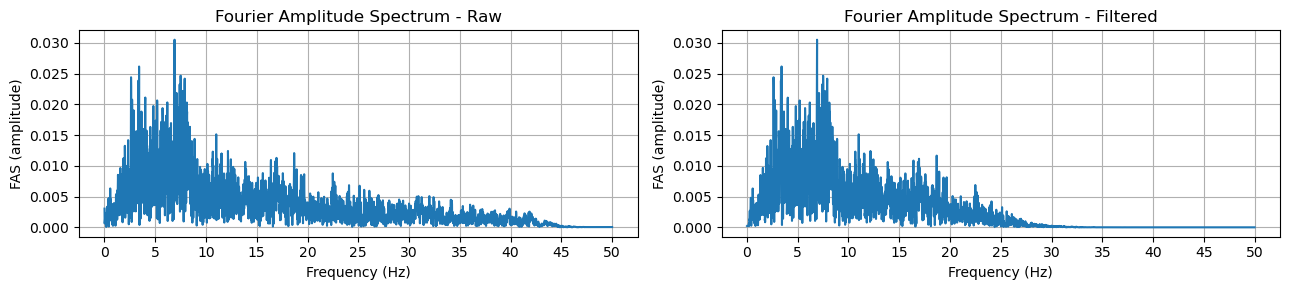

In [5]:
# FFT (FAST FOURIER TRANSFORM)

# FFT of filtered acceleration.
# np.fft.fft returns complex numbers (a + i b).
acc = acc_E
# acc = acc_N
# acc = acc_Y

acc_fft = np.fft.fft(acc)

n = len(acc )
n_half = n // 2

# Frequency axis (Hz) for the positive frequencies (exclude 0 Hz here)
freq = np.arange(1, n_half + 1) / (n * dt)

# Fourier Amplitude Spectrum (single-sided, scaled)
fas = 2.0 * np.abs(acc_fft[1:n_half + 1]) / n

# Phase spectrum (radians)
phase = np.angle(acc_fft[1:n_half + 1])

# Plot: FAS and phase
fig, ax = plt.subplots(1, 2, figsize=(13, 3))
ax[0].plot(freq, fas_raw)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("FAS (amplitude)")
ax[0].set_title("Fourier Amplitude Spectrum - Raw")
ax[0].set_xticks(np.arange(0, fn + 5, 5))
ax[0].grid(True)
ax[1].plot(freq, fas)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("FAS (amplitude)")
ax[1].set_title("Fourier Amplitude Spectrum - Filtered")
ax[1].set_xticks(np.arange(0, fn + 5, 5))
ax[1].grid(True)
fig.tight_layout()
plt.show()

### 4. Exporting Filtered Acceleration Data to a TXT File

In [6]:
def saveAFAD(file_path, acc, t):
    "To save the output into a TXT file."
    file_name = os.path.splitext(os.path.basename(file_path))[0] # Extract original file name (without extension)
    new_name = file_name.replace("unprocessed_RawAcc", "processed_Acc") # Create new name
    output_dir = os.path.dirname(file_path) # Extract the directory of the original file
    data = np.column_stack((t, acc)) # Combine into 2-column array
    output_path = os.path.join(output_dir, f"{new_name}.txt") # Build full output path
    np.savetxt(output_path, data, header="t(sec) acc(g)", fmt=("%.3f", "%.7f")) # Save file
    return output_path
    
# E–W Acc component
output_path = saveAFAD(file_path_E, acc_E, t)
print(f"E–W Acc file saved to: {output_path}")

# N-S Acc component
output_path = saveAFAD(file_path_N, acc_N, t)
print(f"N-S Acc file saved to: {output_path}")

# U-D Acc component
output_path = saveAFAD(file_path_U, acc_U, t)
print(f"U-D Acc file saved to: {output_path}")

E–W Acc file saved to: EQ_Record_Files\20230206011732_4614_processed_Acc_E.txt
N-S Acc file saved to: EQ_Record_Files\20230206011732_4614_processed_Acc_N.txt
U-D Acc file saved to: EQ_Record_Files\20230206011732_4614_processed_Acc_U.txt


### 5. Husid Plot (Cumulative Energy Measure)

Record Duration: 77.01 s
E-W Significant Duration (5–95%): 24.39 s
N-S Significant Duration (5–95%): 23.21 s
U-D Significant Duration (5–95%): 20.81 s


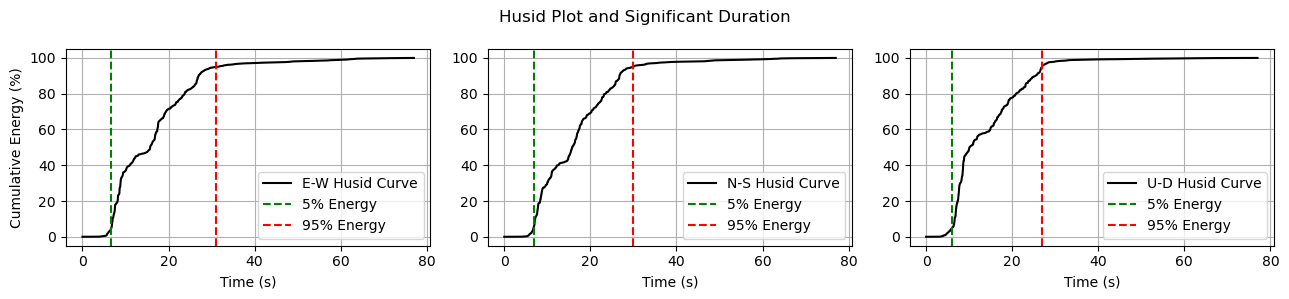

In [7]:
# Husid Plot (Cumulative Energy Measure)
# I(t) = (π / 2g) ∫ a(t)^2 dt
# Significant duration is defined between 5% and 95% of cumulative energy

g = 9.80665  # [m/s^2] gravitational acceleration 

# Compute Husid integral
husid_E = (np.pi / (2 * g)) * np.cumsum(acc_E**2)  # E-W component
husid_N = (np.pi / (2 * g)) * np.cumsum(acc_N**2)  # N-S component
husid_U = (np.pi / (2 * g)) * np.cumsum(acc_U**2)  # U-D component

# Normalize to percentage (%)
husid_E = husid_E / husid_E.max() * 100.0  # E-W component
husid_N = husid_N / husid_N.max() * 100.0  # N-S component
husid_U = husid_U / husid_U.max() * 100.0  # U-D component

# Determine 5%–95% energy indices
idx_start_E = np.where(husid_E >= 5.0)[0][0]  # E-W component
idx_start_N = np.where(husid_N >= 5.0)[0][0]  # N-S component
idx_start_U = np.where(husid_U >= 5.0)[0][0]  # U-D component
idx_end_E = np.where(husid_E >= 95.0)[0][0]  # E-W component
idx_end_N = np.where(husid_N >= 95.0)[0][0]  # N-S component
idx_end_U = np.where(husid_U >= 95.0)[0][0]  # U-D component

# Significant duration
print(f"Record Duration: {dur:.2f} s") # Record duration
sig_duration_E = dt * (idx_end_E - idx_start_E)  # E-W component
sig_duration_N = dt * (idx_end_N - idx_start_N)  # N-S component
sig_duration_U = dt * (idx_end_U - idx_start_U)  # U-D component
print(f"E-W Significant Duration (5–95%): {sig_duration_E:.2f} s")
print(f"N-S Significant Duration (5–95%): {sig_duration_N:.2f} s")
print(f"U-D Significant Duration (5–95%): {sig_duration_U:.2f} s")


# Plot Husid curves (E-W, N-S, U-D) in one figure
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
fig.suptitle("Husid Plot and Significant Duration", fontsize=12)
ax[0].plot(t, husid_E, color='k', label='E-W Husid Curve')
ax[0].axvline(x=dt * idx_start_E, color='g', linestyle='--', label='5% Energy')
ax[0].axvline(x=dt * idx_end_E,   color='r', linestyle='--', label='95% Energy')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Cumulative Energy (%)')
ax[0].grid(True)
ax[0].legend()
ax[1].plot(t, husid_N, color='k', label='N-S Husid Curve')
ax[1].axvline(x=dt * idx_start_N, color='g', linestyle='--', label='5% Energy')
ax[1].axvline(x=dt * idx_end_N,   color='r', linestyle='--', label='95% Energy')
ax[1].set_xlabel('Time (s)')
ax[1].grid(True)
ax[1].legend()
ax[2].plot(t, husid_U, color='k', label='U-D Husid Curve')
ax[2].axvline(x=dt * idx_start_U, color='g', linestyle='--', label='5% Energy')
ax[2].axvline(x=dt * idx_end_U,   color='r', linestyle='--', label='95% Energy')
ax[2].set_xlabel('Time (s)')
ax[2].grid(True)
ax[2].legend()
fig.tight_layout()
plt.show()